# RF and XGB Models

### Notes:
I first ran the models using only RegionType to identify location and I we got the follwing errors:

RF: R² = 0.2325, RMSE = 15.3930
XGB: R² = 0.2626, RMSE = 15.0882

The I added RegionName and I got the following errors:

RF: R² = 0.2452, RMSE = 15.2642
XGB: R² = 0.2998, RMSE = 14.7024

This tells us that region-specific information matters for the model.

In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
from sklearn.preprocessing import LabelEncoder

In [2]:
# read the processed data
data = pd.read_csv("../data/processed/processed_data_low.csv")
data.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,Month,MarketTemp,date,NewConSales,ZHVI_Tier,ZORDI_Condo,ZORDI_MFR,ZORDI_SFR,ZORDI_All,DaysToClose
0,394297,677,"Aberdeen, SD",msa,SD,2020-06-30,59.0,2020-06-01,NaN,171702.082197,NaN,NaN,NaN,NaN,NaN
1,394298,473,"Aberdeen, WA",msa,WA,2020-06-30,97.0,2020-06-01,NaN,235972.537055,NaN,NaN,NaN,NaN,NaN
2,394299,251,"Abilene, TX",msa,TX,2020-06-30,59.0,2020-06-01,34.0,152751.072291,NaN,71.0,104.0,94.0,NaN
3,394300,720,"Ada, OK",msa,OK,2020-06-30,73.0,2020-06-01,NaN,125912.908639,NaN,NaN,NaN,NaN,NaN
4,394302,393,"Adrian, MI",msa,MI,2020-06-30,108.0,2020-06-01,NaN,164669.930398,NaN,NaN,NaN,NaN,NaN


In [3]:
# data set up for XGB and RF models
cols_to_drop = [
    "RegionID",
    "Month",
    "StateName",
    "NewConSales",
    "ZORDI_Condo",
    "ZORDI_MFR",
    "ZORDI_SFR",
    "DaysToClose",
]

df_model = data.drop(columns=cols_to_drop).copy()

df_model = pd.get_dummies(df_model, columns=["RegionType"], drop_first=True)

target_col = "MarketTemp"

df_model["date"] = pd.to_datetime(df_model["date"])
df_model["year"] = df_model["date"].dt.year
df_model["month_num"] = df_model["date"].dt.month
df_model["quarter"] = df_model["date"].dt.quarter

In [4]:
le_region = LabelEncoder()
df_model["RegionName_enc"] = le_region.fit_transform(df_model["RegionName"])

In [5]:
# select target column
target_col = "MarketTemp"

In [6]:
# target lags
for lag in [1, 2, 3, 6, 12]:
    df_model[f"lag_{lag}"] = df_model[target_col].shift(lag)

In [7]:
# rolling stats
df_model["roll_mean_3"] = df_model[target_col].shift(1).rolling(3).mean()
df_model["roll_mean_6"] = df_model[target_col].shift(1).rolling(6).mean()
df_model["roll_std_3"] = df_model[target_col].shift(1).rolling(3).std()

# calendar features
df_model["month"] = df_model["date"].dt.month
df_model["quarter"] = df_model["date"].dt.quarter
df_model["year"] = df_model["date"].dt.year

In [8]:
cols_to_not_include = [target_col, "date", "RegionName"]

feature_cols = [col for col in df_model.columns.to_list() if col not in cols_to_not_include]
df_model = df_model.dropna(subset=feature_cols + [target_col]).copy().reset_index()

In [9]:
df_model

,index,SizeRank,RegionName,MarketTemp,date,ZHVI_Tier,ZORDI_All,year,month_num,quarter,RegionName_enc,lag_1,lag_2,lag_3,lag_6,lag_12,roll_mean_3,roll_mean_6,roll_std_3,month
0,13,62,"Albuquerque, NM",74.0,2020-06-01,224984.782941,247.0,2020,6,2,14,68.0,80.0,63.0,65.0,97.0,70.333333,84.833333,8.736895,6
1,17,70,"Allentown, PA",86.0,2020-06-01,232281.911800,324.0,2020,6,2,19,65.0,60.0,54.0,80.0,79.0,59.666667,66.833333,5.507571,6
2,20,340,"Altoona, PA",48.0,2020-06-01,141334.358685,135.0,2020,6,2,22,62.0,104.0,86.0,54.0,81.0,84.000000,71.833333,21.071308,6
3,22,186,"Amarillo, TX",55.0,2020-06-01,153001.486732,98.0,2020,6,2,24,60.0,48.0,62.0,65.0,63.0,56.666667,70.833333,7.571878,6
4,24,336,"Ames, IA",57.0,2020-06-01,197810.966642,18.0,2020,6,2,26,42.0,55.0,60.0,104.0,68.0,52.333333,61.833333,9.291573,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42497,62790,849,"The Dalles, OR",45.0,2026-01-01,389915.888704,28.0,2026,1,1,838,37.0,59.0,51.0,46.0,40.0,49.000000,46.666667,11.135529,1
42498,62791,55,"Urban Honolulu, HI",46.0,2026-01-01,842224.237311,89.0,2026,1,1,862,45.0,37.0,59.0,30.0,39.0,47.000000,46.500000,11.135529,1
42499,62793,831,"Weatherford, OK",48.0,2026-01-01,171840.419791,18.0,2026,1,1,900,1.0,46.0,45.0,51.0,25.0,30.666667,39.833333,25.696952,1
42500,62794,924,"Winnemucca, NV",50.0,2026-01-01,337816.865275,13.0,2026,1,1,917,48.0,1.0,46.0,59.0,45.0,31.666667,39.333333,26.576932,1


In [10]:
df_model["date"] = pd.to_datetime(df_model["date"])
df_model = df_model.sort_values("date").copy()

sorted_dates = sorted(df_model["date"].unique())
test_dates = sorted_dates[-12:]

train_df = df_model[df_model["date"] < min(test_dates)].copy()
test_df = df_model[df_model["date"].isin(test_dates)].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

In [11]:
# random forest implementation
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=1
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [12]:
# XGB implementation
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

In [13]:
def evaluate_model(y_true, y_pred, model_name):
    results = {
        "Model": model_name,
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred))
    }

    return results

rf_results = evaluate_model(y_test, rf_pred, "Random Forest")
xgb_results = evaluate_model(y_test, xgb_pred, "XGBoost")

metrics_table = pd.DataFrame([rf_results, xgb_results]).round(4)
print(metrics_table)

           Model      R2     RMSE
0  Random Forest  0.2443  15.2820
1        XGBoost  0.3003  14.7048


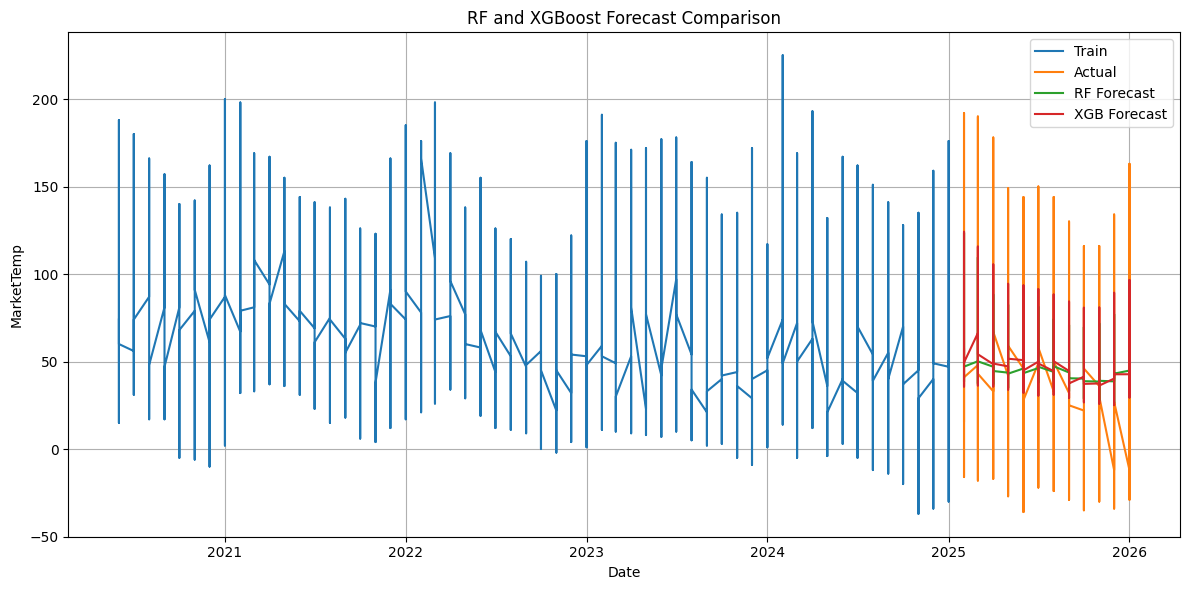

In [14]:
plt.figure(figsize=(12, 6))
plt.plot(train_df["date"], y_train, label="Train")
plt.plot(test_df["date"], y_test, label="Actual")
plt.plot(test_df["date"], rf_pred, label="RF Forecast")
plt.plot(test_df["date"], xgb_pred, label="XGB Forecast")
plt.title("RF and XGBoost Forecast Comparison")
plt.xlabel("Date")
plt.ylabel(target_col)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

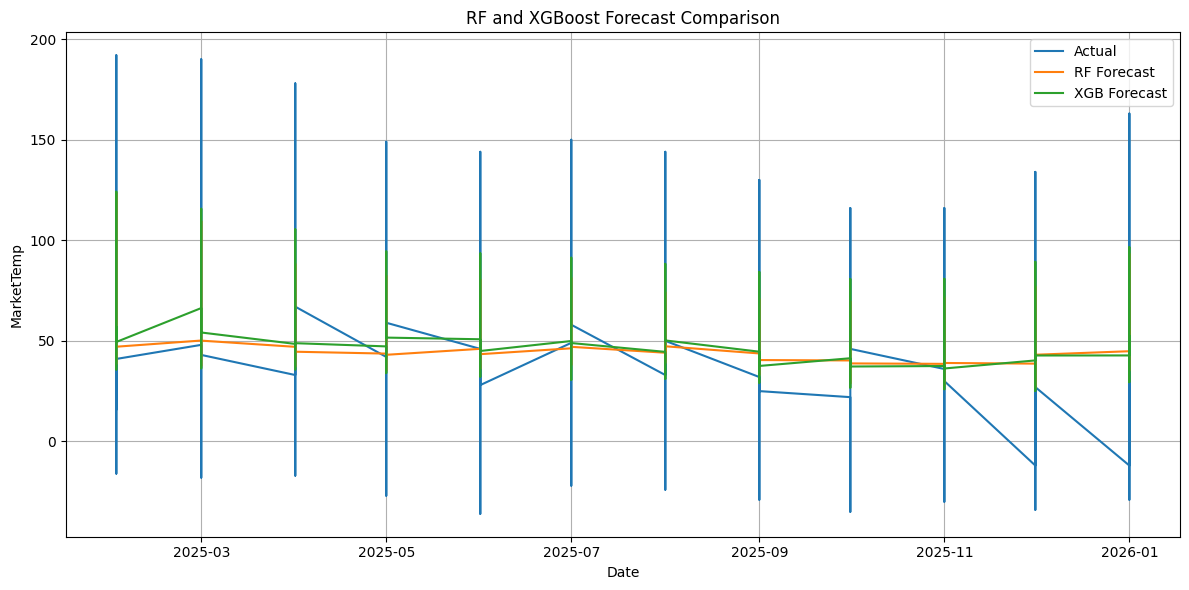

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(test_df["date"], y_test, label="Actual")
plt.plot(test_df["date"], rf_pred, label="RF Forecast")
plt.plot(test_df["date"], xgb_pred, label="XGB Forecast")
plt.title("RF and XGBoost Forecast Comparison")
plt.xlabel("Date")
plt.ylabel(target_col)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()